In [1]:
from datasets import load_dataset
import numpy as np

c:\Ai\sma-sa-llms\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds= load_dataset("imdb")

In [3]:
ds


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [4]:
train_df = ds['train'].to_pandas()

In [5]:
train_df.sample(10)

,text,label
16166,'The Rookie' was a wonderful movie about the s...,1
438,"Sure, I like short cartoons, but I didn't like...",0
8681,Just kidding! This was one of the worst movies...,0
90,Devil Hunter gained notoriety for the fact tha...,0
22552,This movie re-wrote film history in every way....,1
3568,this movie had more holes than a piece of swis...,0
20044,I am and was very entertained by the movie. It...,1
4122,"Unbelievably bad acting, a no good, unclear st...",0
3851,"in fact,it's basically the same movie.and they...",0
13581,This is one of the few comedies I can watch ag...,1


In [6]:
train_df['label'].value_counts()

label
0    12500
1    12500
Name: count, dtype: int64

In [7]:
train_df['sentiment'] = np.where(train_df.label==1,"positive","negative")

In [8]:
train_df

,text,label,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,negative
1,"""I Am Curious: Yellow"" is a risible and preten...",0,negative
2,If only to avoid making this type of film in t...,0,negative
3,This film was probably inspired by Godard's Ma...,0,negative
4,"Oh, brother...after hearing about this ridicul...",0,negative
...,...,...,...
24995,A hit at the time but now better categorised a...,1,positive
24996,I love this movie like no other. Another time ...,1,positive
24997,This film and it's sequel Barry Mckenzie holds...,1,positive
24998,'The Adventures Of Barry McKenzie' started lif...,1,positive


In [9]:
train_df.sentiment.value_counts()

sentiment
negative    12500
positive    12500
Name: count, dtype: int64

<Axes: >

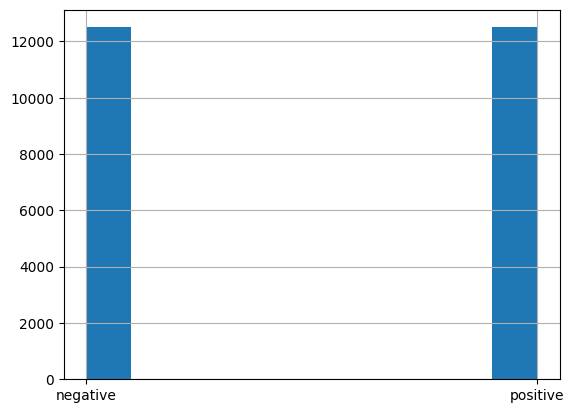

In [11]:
train_df.sentiment.hist()

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
examples_df, gold_examples_df=train_test_split(
    train_df,test_size=0.2,random_state=123
)

In [14]:
examples_df.shape,gold_examples_df.shape

((20000, 3), (5000, 3))

In [16]:
columns=['text','sentiment']
gold_examples=(gold_examples_df[columns]
               .sample(20,random_state=34)).to_json(orient='records')

In [18]:
import json

In [21]:
json.loads(gold_examples)[0]

{'text': '"A Guy Thing" may not be a classic, but it sure is a good, funny comedy. The plot focuses on Paul (Jason Lee), who wakes up the morning after his bachelor party with no memory and Becky (Julia Stiles) lying naked in his bed. Before he can figure out what happened, he rushes Becky out of his apartment because his fiance Karen (Selma Blair) is coming. After that, as you could imagine, chaos ensues.<br /><br />Almost every single scene in "A Guy Thing" delivers loud laughs. The funniest moments come from when Paul imagines what could happen if he tells Karen. Selma Blair is a truly talented comedian, and the worst thing about this film is that she goes underused. Although, she turns out to be more funny than Stiles\' character, who actually isn\'t that interesting. Of course, not every comedy is perfect.<br /><br />As I said, "A Guy Thing" is no classic, but it\'s not bad either, 7/10.',
 'sentiment': 'positive'}

In [25]:
user_prompt_template = """"```{movie_review}```"""

In [23]:
zero_shot_prompt_system="""
Classify the sentiment of movie reviews presented in the input as positive or negative
Movie reviews will be delimited by triple backticks ``` int the input 
Answer only as 'positive' or 'negative'
Do not explain your answer
"""

In [24]:
zero_shot_prompt=[{"role":"system","content":zero_shot_prompt_system}]

In [61]:
few_shot_prompt_system="""
Classify the sentiment of movie reviews presented in the input as positive or negative
Movie reviews will be delimited by triple backticks ``` int the input 
Answer only as 'positive' or 'negative'
Do not explain your answer
"""

In [27]:
examples_df.shape

(20000, 3)

In [45]:
positive_reviews_df = (examples_df[examples_df['sentiment']=='positive'][columns]
                       .sample(4))

In [46]:
negative_reviews_df=(examples_df[examples_df['sentiment']=='negative'][columns]
                     .sample(4))

In [48]:
positive_reviews_df

,text,sentiment
21554,Rock n' roll is a messy business and DiG! demo...,positive
21445,I really enjoyed this drama from Sidney Lumet....,positive
17118,Despite the lack of logic present in the story...,positive
23103,"""Emma"" was a product of what might be called b...",positive


In [62]:
negative_reviews_df

,text,sentiment
5417,This programme bugs me! There is no humour to ...,negative
9463,You can often tell a movie didn't turn out lik...,negative
9601,This a fascinatingly awful movie. It make so l...,negative
568,I bought this adaptation because I really like...,negative


In [47]:
positive_reviews_df.shape,negative_reviews_df.shape

((4, 2), (4, 2))

In [41]:
import pandas as pd

In [63]:
ex=pd.concat([positive_reviews_df,negative_reviews_df])

In [64]:
ex

,text,sentiment
21554,Rock n' roll is a messy business and DiG! demo...,positive
21445,I really enjoyed this drama from Sidney Lumet....,positive
17118,Despite the lack of logic present in the story...,positive
23103,"""Emma"" was a product of what might be called b...",positive
5417,This programme bugs me! There is no humour to ...,negative
9463,You can often tell a movie didn't turn out lik...,negative
9601,This a fascinatingly awful movie. It make so l...,negative
568,I bought this adaptation because I really like...,negative


In [57]:
examples=examples_df.sample(4*2,replace=False).to_json(orient='records')

In [58]:
json.loads(examples)

[{'text': "Absolute garbage. The reason that this is so terrible is not because it deviated from the formula, but because the plot was just pathetic. <br /><br />The supposed star didn't do anything to solve the case - and neither did anyone else really - it was just routine police work. Utterly tedious.<br /><br />You sat right till the end hoping for a twist - and got nothing but a huge sense of disappointment. <br /><br />There was so much potential in having a relative in apparent kidnap. Could the Lt's personal involvement finally cloud his judgement? <br /><br />All the obvious signs were of a stranger doing it. But surely a genius like Lt C, by constant conversation with the wronged husband, would gradually uncover a fiendish plot involving a tape recorder playing in the shower room while a masked groom surprises the bride, hides the body and then plants subtle clues. It could have been good. It was a complete waste of time.",
  'label': 0,
  'sentiment': 'negative'},
 {'text': 

In [59]:
def create_examples(dataset,n=4):
    positive_reviews_df = (dataset[dataset['sentiment']=='positive'][columns]
                       .sample(n))
    negative_reviews_df = (dataset[dataset['sentiment']=='negative'][columns]
                       .sample(n))
    examples_df=pd.concat([positive_reviews_df,negative_reviews_df])
    examples=examples_df.sample(2*n,replace=False)
    return examples.to_json(orient='records')

In [60]:
examples_df.shape

(20000, 3)

In [73]:
few_shot_examples=create_examples(examples_df,n=2)

In [74]:
json.loads(few_shot_examples)

[{'text': 'I second the motion to make this into a movie, it would be great!! I was also amazed at the storyline and character build in this game. I have played it again and again (over 20 times) just to try something different and it gets more interesting every time. Final Fantasy eat your heart out!! THIS SHOULD BE MADE INTO A MOVIE!!!!! If anyone out there wants some help to start a petition to have this made into a movie, please contact me. I would love to help with that project any day. The graphics are great for PS1 and even make you forget it is PS1 most of the time. The multitude of side quests makes it different every time you play.',
  'sentiment': 'positive'},
 {'text': 'Look, I\'m sorry if half the world takes offense at this, but life is confusing enough. I don\'t need to watch it that way. I dig Anthony Hopkins, big time. I even watched Fracture, and I knew that would be a steaming pile of Quentin. But this thing is not well shot, and it\'s not daring--even if it is artsy

In [77]:
def create_prompt(system_message,examples,user_prompt_template):
    prompt=[
        {"role":"system","content":system_message}
    ]
    for example in json.loads(examples)  :
        review = example['text']
        sentiment = example['sentiment']
        prompt.append({"role":"user","content":user_prompt_template.format(movie_review=review)})
        prompt.append({"role":"assistant","content":f"{sentiment}"})
    return prompt

In [78]:
few_shot_prompt = create_prompt(few_shot_prompt_system,few_shot_examples,user_prompt_template)

In [79]:
few_shot_prompt

[{'role': 'system',
  'content': "\nClassify the sentiment of movie reviews presented in the input as positive or negative\nMovie reviews will be delimited by triple backticks ``` int the input \nAnswer only as 'positive' or 'negative'\nDo not explain your answer\n"},
 {'role': 'user',
  'content': '"```I second the motion to make this into a movie, it would be great!! I was also amazed at the storyline and character build in this game. I have played it again and again (over 20 times) just to try something different and it gets more interesting every time. Final Fantasy eat your heart out!! THIS SHOULD BE MADE INTO A MOVIE!!!!! If anyone out there wants some help to start a petition to have this made into a movie, please contact me. I would love to help with that project any day. The graphics are great for PS1 and even make you forget it is PS1 most of the time. The multitude of side quests makes it different every time you play.```'},
 {'role': 'assistant', 'content': 'positive'},
 {'

In [80]:
cot_few_shot_prompt_system="""
Classify the sentiment of movie reviews presented in the input as positive or negative
Movie reviews will be delimited by triple backticks ``` int the input 
Answer only as 'positive' or 'negative'
Do not explain your answer

Instruction:
1. Carefully read the text of the review and think through the options for sentiment provided
2. Consider the overall sentiment of the review and estimate the probability of the review being positive

To reiterate, your answer should strictly only contain the label: positive or negative 
"""

In [81]:
cot_few_shot_prompt = create_prompt(
    cot_few_shot_prompt_system,
    few_shot_examples,
    user_prompt_template)

In [82]:
cot_few_shot_prompt

[{'role': 'system',
  'content': "\nClassify the sentiment of movie reviews presented in the input as positive or negative\nMovie reviews will be delimited by triple backticks ``` int the input \nAnswer only as 'positive' or 'negative'\nDo not explain your answer\n\nInstruction:\n1. Carefully read the text of the review and think through the options for sentiment provided\n2. Consider the overall sentiment of the review and estimate the probability of the review being positive\n\nTo reiterate, your answer should strictly only contain the label: positive or negative \n"},
 {'role': 'user',
  'content': '"```I second the motion to make this into a movie, it would be great!! I was also amazed at the storyline and character build in this game. I have played it again and again (over 20 times) just to try something different and it gets more interesting every time. Final Fantasy eat your heart out!! THIS SHOULD BE MADE INTO A MOVIE!!!!! If anyone out there wants some help to start a petition

In [83]:
from sklearn.metrics import f1_score 

In [84]:
def evaluate_prompt(prompt,gold_examples,user_prompt_template,llm):
    predicted_sentiments=[]
    ground_truth_sentiments=[]
    for example in json.loads(gold_examples):
        review = example['text']
        sentiment=example['sentiment']
        user_input = [{"role":"user","content":user_prompt_template.format(movie_review=review)}]
        
        try: 
            resp=llm.invoke(prompt+user_input)
            if 'negative' in resp.content.strip().lower():
                predicted ='negative'
            
            elif 'positive' in resp.content.strip().lower():
                predicted ='positive'
            else:
                predicted = 'unknown'
            predicted_sentiments.append(predicted)
            ground_truth_sentiments.append(sentiment)
        except Exception as e:
            print(e)
            continue
        return f1_score(ground_truth_sentiments,predicted_sentiments,average="micro")
            


In [90]:
from dotenv.ipython import load_dotenv

In [91]:
load_dotenv(override=True)

True

In [92]:
from langchain_openai import ChatOpenAI

In [93]:
llm1 = ChatOpenAI(model="gpt-4o",temperature=0)